In [2]:
# Load the full dataset to perform detailed analysis
import  pandas as pd
full_data_path = 'Drug_overdose.csv'
full_data = pd.read_csv(full_data_path)

# Get a summary of the dataset, including checking for missing values in key columns
full_data.info(), full_data.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6228 entries, 0 to 6227
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   INDICATOR       6228 non-null   object 
 1   PANEL           6228 non-null   object 
 2   PANEL_NUM       6228 non-null   int64  
 3   UNIT            6228 non-null   object 
 4   UNIT_NUM        6228 non-null   int64  
 5   STUB_NAME       6228 non-null   object 
 6   STUB_NAME_NUM   6228 non-null   int64  
 7   STUB_LABEL      6228 non-null   object 
 8   STUB_LABEL_NUM  6228 non-null   float64
 9   YEAR            6228 non-null   int64  
 10  YEAR_NUM        6228 non-null   int64  
 11  AGE             6228 non-null   object 
 12  AGE_NUM         6228 non-null   float64
 13  ESTIMATE        5117 non-null   float64
 14  FLAG            1111 non-null   object 
dtypes: float64(3), int64(5), object(7)
memory usage: 730.0+ KB


(None,
                         INDICATOR                     PANEL    PANEL_NUM  \
 count                        6228                      6228  6228.000000   
 unique                          1                         6          NaN   
 top     Drug overdose death rates  All drug overdose deaths          NaN   
 freq                         6228                      1038          NaN   
 mean                          NaN                       NaN     2.500000   
 std                           NaN                       NaN     1.707962   
 min                           NaN                       NaN     0.000000   
 25%                           NaN                       NaN     1.000000   
 50%                           NaN                       NaN     2.500000   
 75%                           NaN                       NaN     4.000000   
 max                           NaN                       NaN     5.000000   
 
                                                  UNIT     UNIT_NUM

In [3]:
# Replace NaN values in 'ESTIMATE' with 0 for calculation purposes (assumes no data means no reported deaths, could be debated)
full_data['ESTIMATE'].fillna(0, inplace=True)

# Confirm replacement
full_data['ESTIMATE'].isnull().sum()


0

In [4]:
# Grouping the data by 'STUB_LABEL' and 'YEAR' to find average estimates per demographic group per year
grouped_data = full_data.groupby(['STUB_LABEL', 'YEAR'])['ESTIMATE'].mean().reset_index()

# Pivoting the data for better visualization
pivot_table = grouped_data.pivot(index='YEAR', columns='STUB_LABEL', values='ESTIMATE')

# Showing a preview of the pivoted data
pivot_table.head(), pivot_table.columns


(STUB_LABEL  15-24 years  25-34 years  35-44 years  45-54 years  55-64 years  \
 YEAR                                                                          
 1999           1.000000     2.533333     4.450000     3.466667     1.166667   
 2000           1.166667     2.500000     4.516667     3.683333     1.216667   
 2001           1.400000     2.750000     4.933333     4.166667     1.416667   
 2002           1.733333     3.466667     5.916667     5.316667     1.766667   
 2003           2.083333     3.800000     6.133333     5.883333     2.066667   
 
 STUB_LABEL  65-74 years  75-84 years  85 years and over  All persons  \
 YEAR                                                                   
 1999           0.550000     0.566667           0.633333     1.875000   
 2000           0.466667     0.450000           0.733333     1.933333   
 2001           0.533333     0.516667           0.700000     2.116667   
 2002           0.716667     0.600000           0.866667     2.625000   


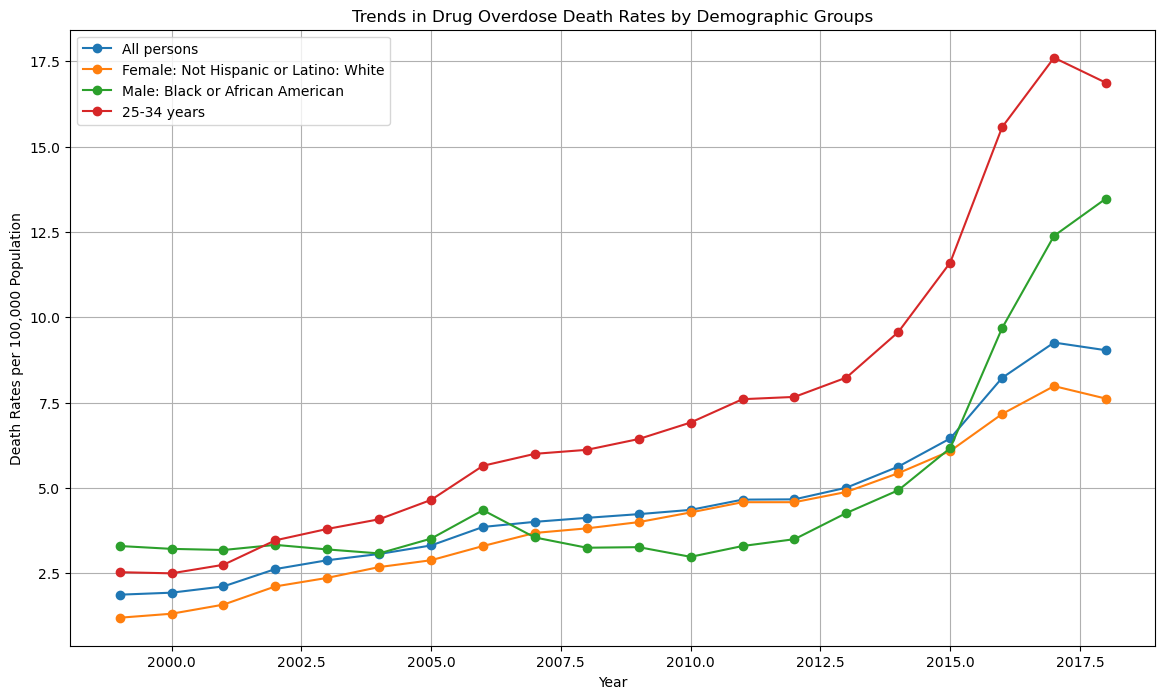

In [5]:
import matplotlib.pyplot as plt

# Set up the plotting environment
plt.figure(figsize=(14, 8))

# Plotting multiple groups for comparison
# Example groups: "All persons", "Female: Not Hispanic or Latino: White", "Male: Black or African American", and "25-34 years"
plt.plot(pivot_table.index, pivot_table['All persons'], label='All persons', marker='o')
plt.plot(pivot_table.index, pivot_table['Female: Not Hispanic or Latino: White'], label='Female: Not Hispanic or Latino: White', marker='o')
plt.plot(pivot_table.index, pivot_table['Male: Black or African American'], label='Male: Black or African American', marker='o')
plt.plot(pivot_table.index, pivot_table['25-34 years'], label='25-34 years', marker='o')

# Adding titles and labels
plt.title('Trends in Drug Overdose Death Rates by Demographic Groups')
plt.xlabel('Year')
plt.ylabel('Death Rates per 100,000 Population')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


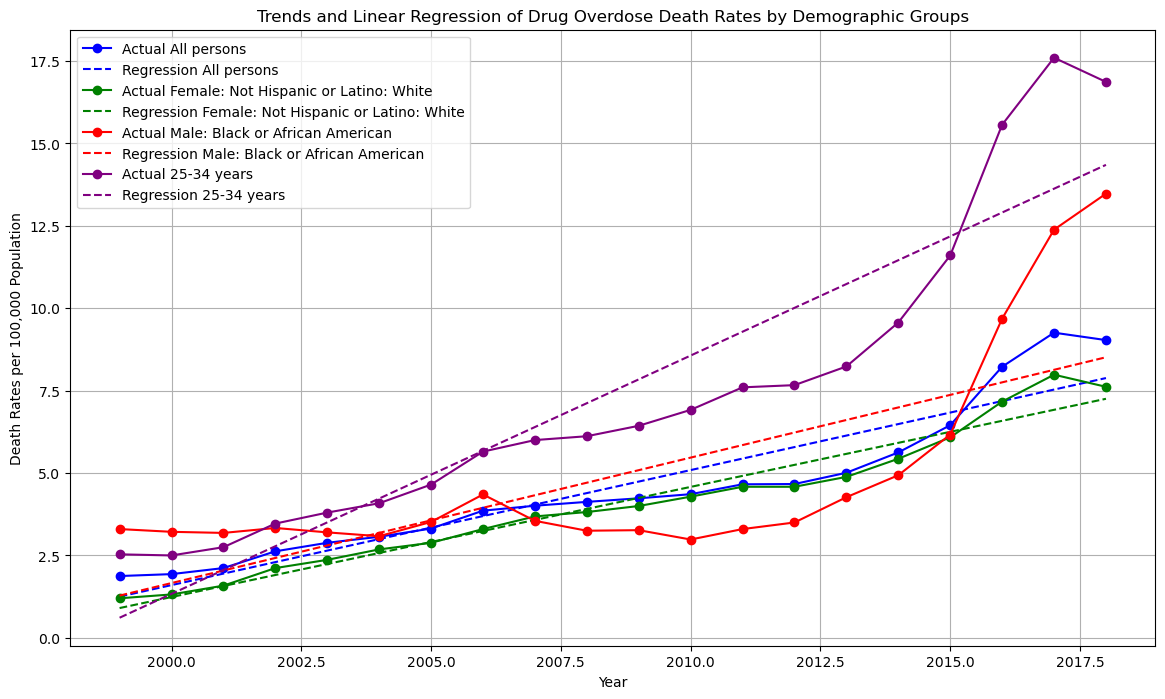

In [6]:
from scipy.stats import linregress

# Set up the plotting environment
plt.figure(figsize=(14, 8))

# Groups to analyze with regression
groups = ['All persons', 'Female: Not Hispanic or Latino: White', 
          'Male: Black or African American', '25-34 years']

colors = ['blue', 'green', 'red', 'purple']  # Colors for the lines

for group, color in zip(groups, colors):
    # Actual data
    plt.plot(pivot_table.index, pivot_table[group], label=f'Actual {group}', marker='o', color=color)
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(pivot_table.index, pivot_table[group])
    # Calculate the line of best fit
    line = slope * pivot_table.index + intercept
    # Plot the line of best fit
    plt.plot(pivot_table.index, line, label=f'Regression {group}', linestyle='--', color=color)

# Adding titles and labels
plt.title('Trends and Linear Regression of Drug Overdose Death Rates by Demographic Groups')
plt.xlabel('Year')
plt.ylabel('Death Rates per 100,000 Population')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [7]:
import statsmodels.api as sm

# Dictionary to store regression results for easier access
regression_results = {}

for group in groups:
    # Adding a constant to the input features
    X = sm.add_constant(pivot_table.index)  # adding a constant
    y = pivot_table[group]
    
    # Creating the model
    model = sm.OLS(y, X)
    results = model.fit()
    
    # Store results in dictionary
    regression_results[group] = results

    # Print the summary for each group
    print(f"Regression Summary for {group}:")
    print(results.summary())
    print("\n\n")


Regression Summary for All persons:
                            OLS Regression Results                            
Dep. Variable:            All persons   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     132.4
Date:                Sat, 27 Apr 2024   Prob (F-statistic):           9.87e-10
Time:                        23:00:54   Log-Likelihood:                -22.406
No. Observations:                  20   AIC:                             48.81
Df Residuals:                      18   BIC:                             50.80
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -696